# 08 - Best Checkpoint and MLflow Review

Use this notebook after running the best-checkpoint experiments. It summarizes local JSON/CSV artifacts and, when available, the local MLflow tracking database.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

REPORTS_DIR = PROJECT_ROOT / "models" / "reports"
PREDICTIONS_DIR = PROJECT_ROOT / "outputs" / "predictions"
MLFLOW_DB = PROJECT_ROOT / "mlflow.db"

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

PROJECT_ROOT

WindowsPath('C:/Users/z004hn4c/Documents/Estudo/LLMOps And AIOps Bootcamp With 8 End To End Projects/nexar-dashcam-collision-prediction')

In [2]:
def read_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def scalar(value):
    return None if value is None else float(value)


training_rows = []
for path in sorted(REPORTS_DIR.glob("*_metrics.json")):
    report = read_json(path)
    if "frame_metrics" not in report:
        continue
    final_metrics = report.get("frame_metrics", {})
    best_metrics = report.get("best_frame_metrics") or {}
    training_rows.append(
        {
            "experiment": path.name.replace("_metrics.json", ""),
            "pretrained": report.get("config", {}).get("pretrained"),
            "epochs_ran": len(report.get("history", [])),
            "early_stopped": report.get("early_stopped"),
            "best_epoch": report.get("best_epoch"),
            "monitor": report.get("best_monitor_metric"),
            "best_monitor_value": scalar(report.get("best_monitor_value")),
            "best_val_f1": scalar(best_metrics.get("f1")),
            "best_val_roc_auc": scalar(best_metrics.get("roc_auc")),
            "final_val_f1": scalar(final_metrics.get("f1")),
            "final_val_roc_auc": scalar(final_metrics.get("roc_auc")),
            "train_frames": report.get("train_frames"),
            "val_frames": report.get("val_frames"),
            "best_checkpoint_path": report.get("best_checkpoint_path"),
        }
    )

training_df = pd.DataFrame(training_rows)
training_df.sort_values(["best_val_roc_auc", "best_val_f1"], ascending=False, na_position="last")

,experiment,pretrained,epochs_ran,early_stopped,best_epoch,monitor,best_monitor_value,best_val_f1,best_val_roc_auc,final_val_f1,final_val_roc_auc,train_frames,val_frames,best_checkpoint_path
2,temporal_alert_224_pretrained,True,6,True,3.0,roc_auc,0.598851,0.057803,0.598851,0.077922,0.558073,6209,1551,C:\Users\z004hn4c\Documents\Estudo\LLMOps And ...
3,temporal_alert_224_split,False,3,False,2.0,roc_auc,0.514114,0.136986,0.514114,0.093190,0.501759,6209,1551,C:\Users\z004hn4c\Documents\Estudo\LLMOps And ...
0,baseline,False,3,None,NaN,None,NaN,NaN,NaN,0.608696,0.560400,400,100,None
1,temporal_alert_224,False,3,None,NaN,None,NaN,NaN,NaN,0.128342,0.517565,6209,1551,None


In [3]:
alert_rows = []
for path in sorted(REPORTS_DIR.glob("*_alert_metrics.json")):
    report = read_json(path)
    metrics = report.get("metrics", {})
    config = report.get("config", {})
    alert_rows.append(
        {
            "experiment": path.name.replace("_alert_metrics.json", ""),
            "split": config.get("split"),
            "threshold": scalar(config.get("threshold")),
            "videos": metrics.get("videos"),
            "precision": scalar(metrics.get("alert_precision")),
            "recall": scalar(metrics.get("alert_recall")),
            "false_alarm_rate": scalar(metrics.get("false_alarm_rate")),
            "missed_event_rate": scalar(metrics.get("missed_event_rate")),
            "mean_lead_time": scalar(metrics.get("mean_predicted_lead_time")),
            "mean_alert_error": scalar(metrics.get("mean_alert_time_error")),
            "checkpoint": config.get("checkpoint_path"),
        }
    )

alert_df = pd.DataFrame(alert_rows)
alert_df.sort_values(["recall", "false_alarm_rate"], ascending=[False, True], na_position="last")

,experiment,split,threshold,videos,precision,recall,false_alarm_rate,missed_event_rate,mean_lead_time,mean_alert_error,checkpoint
0,temporal_alert_224,None,0.5,100,0.607595,0.96,0.62,0.04,14.689979,-13.150417,models\checkpoints\temporal_alert_224_resnet18.pt
4,temporal_alert_224_split_best,val,0.5,20,0.533333,0.80,0.70,0.20,16.508250,-14.366375,models\checkpoints\temporal_alert_224_split_be...
3,temporal_alert_224_split,val,0.5,20,0.444444,0.40,0.50,0.60,19.952500,-17.959500,models\checkpoints\temporal_alert_224_split_re...
1,temporal_alert_224_pretrained,val,0.5,20,0.500000,0.30,0.30,0.70,12.010667,-9.774333,models\checkpoints\temporal_alert_224_pretrain...
2,temporal_alert_224_pretrained_best,val,0.5,20,0.500000,0.30,0.30,0.70,13.748000,-11.793667,models\checkpoints\temporal_alert_224_pretrain...


In [4]:
def choose_operating_point(sweep_df: pd.DataFrame, min_recall: float):
    candidates = sweep_df[sweep_df["alert_recall"] >= min_recall].copy()
    if candidates.empty:
        return None
    return candidates.sort_values(
        ["false_alarm_rate", "missed_event_rate", "alert_precision", "mean_alert_time_error"],
        ascending=[True, True, False, False],
    ).iloc[0]


operating_rows = []
for path in sorted(REPORTS_DIR.glob("*_alert_threshold_sweep.csv")):
    sweep_df = pd.read_csv(path)
    experiment = path.name.replace("_alert_threshold_sweep.csv", "")
    for min_recall in [0.7, 0.6, 0.5, 0.4, 0.3]:
        point = choose_operating_point(sweep_df, min_recall)
        if point is None:
            continue
        operating_rows.append(
            {
                "experiment": experiment,
                "min_recall": min_recall,
                "threshold": point["threshold"],
                "precision": point["alert_precision"],
                "recall": point["alert_recall"],
                "false_alarm_rate": point["false_alarm_rate"],
                "missed_event_rate": point["missed_event_rate"],
                "mean_alert_error": point["mean_alert_time_error"],
            }
        )

operating_df = pd.DataFrame(operating_rows)
operating_df.sort_values(["min_recall", "false_alarm_rate", "precision"], ascending=[False, True, False])

,experiment,min_recall,threshold,precision,recall,false_alarm_rate,missed_event_rate,mean_alert_error
0,temporal_alert_224,0.7,0.92,0.948718,0.74,0.04,0.26,-5.025297
9,temporal_alert_224_pretrained_best,0.7,0.23,0.666667,0.80,0.40,0.20,-7.616375
19,temporal_alert_224_split_best,0.7,0.65,0.636364,0.70,0.40,0.30,-14.494571
14,temporal_alert_224_split,0.7,0.19,0.466667,0.70,0.80,0.30,-14.351714
1,temporal_alert_224,0.6,0.95,1.000000,0.60,0.00,0.40,-3.001900
20,temporal_alert_224_split_best,0.6,0.66,0.666667,0.60,0.30,0.40,-15.638167
10,temporal_alert_224_pretrained_best,0.6,0.23,0.666667,0.80,0.40,0.20,-7.616375
5,temporal_alert_224_pretrained,0.6,0.10,0.600000,0.60,0.40,0.40,-12.338167
15,temporal_alert_224_split,0.6,0.31,0.461538,0.60,0.70,0.40,-13.835833
2,temporal_alert_224,0.5,0.95,1.000000,0.60,0.00,0.40,-3.001900


In [6]:
try:
    import mlflow

    mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB.as_posix()}")
    experiments = mlflow.search_experiments()
    experiment_ids = [experiment.experiment_id for experiment in experiments]
    runs = mlflow.search_runs(experiment_ids=experiment_ids, output_format="pandas")
    if runs.empty:
        print("No MLflow runs found in mlflow.db yet.")
    else:
        interesting_cols = [
            "experiment_id",
            "run_id",
            "status",
            "start_time",
            "tags.stage",
            "tags.experiment_name",
            "params.stage",
            "params.monitor_metric",
            "metrics.best_epoch",
            "metrics.best_monitor_value",
            "metrics.best_val_roc_auc",
            "metrics.best_val_f1",
            "metrics.alert_alert_recall",
            "metrics.alert_false_alarm_rate",
            "metrics.candidate_threshold",
        ]
        existing_cols = [column for column in interesting_cols if column in runs.columns]
        mlflow_runs_df = runs[existing_cols].sort_values("start_time", ascending=False)
        mlflow_runs_df.head(30)
except Exception as exc:
    print(f"Could not load MLflow runs: {exc}")

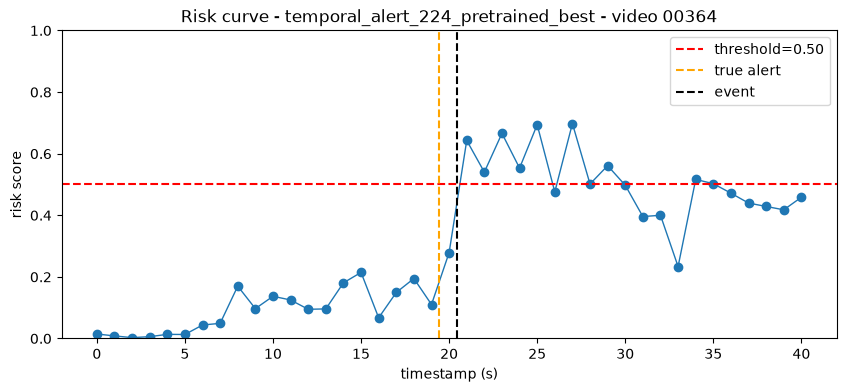

In [7]:
EXPERIMENT = "temporal_alert_224_pretrained_best"

risk_path = PREDICTIONS_DIR / f"{EXPERIMENT}_temporal_risk_scores.csv"
metrics_path = REPORTS_DIR / f"{EXPERIMENT}_alert_metrics.json"
sample_path = PROJECT_ROOT / "data" / "interim" / "sample_100_videos_splits.csv"

if not risk_path.exists():
    print(f"Risk score file not found yet: {risk_path}")
else:
    risk_df = pd.read_csv(risk_path, dtype={"id": str})
    sample_df = pd.read_csv(sample_path, dtype={"id": str})
    report = read_json(metrics_path) if metrics_path.exists() else {"config": {"threshold": 0.5}}
    threshold = float(report.get("config", {}).get("threshold", 0.5))
    candidate = sample_df[(sample_df["split"] == "val") & (sample_df["target"] == 1)].iloc[0]
    video_scores = risk_df[risk_df["id"] == candidate["id"]].copy()

    plt.figure(figsize=(10, 4))
    plt.plot(video_scores["timestamp"], video_scores["risk_score"], marker="o", linewidth=1)
    plt.axhline(threshold, color="red", linestyle="--", label=f"threshold={threshold:.2f}")
    plt.axvline(float(candidate["time_of_alert"]), color="orange", linestyle="--", label="true alert")
    plt.axvline(float(candidate["time_of_event"]), color="black", linestyle="--", label="event")
    plt.title(f"Risk curve - {EXPERIMENT} - video {candidate['id']}")
    plt.xlabel("timestamp (s)")
    plt.ylabel("risk score")
    plt.ylim(0, 1)
    plt.legend()
    plt.show()